<a href="https://colab.research.google.com/github/mohamadfaisalbashir/Introduction-to-Machine-Learning-with-Python/blob/main/05_model_evaluation_and_improvement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Model evaluation and improvement**
This notebook covers model evaluation and improvement:

1. Cross-Validation (k-Fold, Stratified, Leave-One-Out, Shuffle-Split)
2. Grid Search (Parameter Tuning, GridSearchCV, Nested Cross-Validation)
3. Evaluation Metrics and Scoring (Binary Classification, Multiclass, Regression)
4. Using Evaluation Metrics in Model Selection
5. Summary

## **Setup**

In [1]:
!pip install -q mglearn

In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import mglearn
import warnings
warnings.filterwarnings('ignore')


# Patch mglearn.tools.heatmap for numpy/matplotlib compatibility
# (fixes "Only length-1 arrays can be converted to Python scalars" error)
import mglearn.tools as _mt
def _patched_heatmap(values, xlabel, ylabel, xticklabels, yticklabels,
                     cmap=None, vmin=None, vmax=None, ax=None, fmt="%0.2f"):
    if ax is None:
        ax = plt.gca()
    values = np.array(values, dtype=np.float64)
    img = ax.pcolor(values, cmap=cmap, vmin=vmin, vmax=vmax)
    img.update_scalarmappable()
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_xticks(np.arange(len(xticklabels)) + .5)
    ax.set_yticks(np.arange(len(yticklabels)) + .5)
    ax.set_xticklabels(xticklabels)
    ax.set_yticklabels(yticklabels)
    ax.set_aspect(1)
    for p, color, value in zip(img.get_paths(), img.get_facecolors(),
                               values.ravel()):
        x, y = p.vertices[:-2, :].mean(0)
        c = 'k' if np.mean(color[:3]) > 0.5 else 'w'
        ax.text(x, y, fmt % float(value), color=c, ha="center", va="center")
    return img
_mt.heatmap = _patched_heatmap

## **Introduction**

Now that we have established a solid foundation in both supervised and unsupervised learning, and explored a variety of machine learning algorithms, it is time to shift our focus toward a more rigorous phase: evaluating our models and fine-tuning their parameters. Moving forward, our primary focus will be on supervised methods, specifically regression and classification. This deliberate choice is largely because evaluating unsupervised models tends to be a highly qualitative and subjective process—as we observed in our previous discussions—making standard quantitative assessments much less straightforward.

Up to this point, our standard approach for evaluating these supervised models has been relatively straightforward but effective. We typically begin by partitioning our dataset into distinct training and testing sets utilizing the train_test_split function. Following this data preparation, we train our model on the training set by invoking the fit method, and subsequently measure its performance on the unseen test data using the score method, which, in the context of classification, conveniently calculates the fraction of correctly predicted samples. To better illustrate this standard workflow, let us examine a practical example.

In [3]:
from sklearn.datasets import make_blobs
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# create a synthetic dataset
X, y = make_blobs(random_state=0)
# split data and labels into a training and a test set
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)
# instantiate a model and fit it to the training set
logreg = LogisticRegression().fit(X_train, y_train)
# evaluate the model on the test set
print("Test set score: {:.2f}".format(logreg.score(X_test, y_test)))

Test set score: 0.88


Fundamentally, the primary goal of splitting our dataset into training and test sets is to evaluate how effectively our model generalizes to new, unseen data, rather than merely assessing how well it memorizes the training set. To build upon this core concept, we will explore cross-validation as a more rigorous technique for assessing this generalization capability, alongside advanced evaluation metrics for both classification and regression tasks that provide much deeper insights than standard default measures like accuracy and R-squared. Furthermore, we will delve into grid search, which serves as a systematic and highly effective approach for fine-tuning our supervised model's hyperparameters to ensure the best possible predictive performance.



## **1. Cross-Validation**

Evaluating a model based on a single train-test split heavily depends on how the data is randomly divided, which can lead to overly optimistic or pessimistic results. Cross-validation solves this by splitting the data repeatedly and training multiple models, providing a much more robust and statistically stable measure of a model's generalization performance. For classification, Stratified k-Fold is highly recommended to preserve the proportion of classes across all folds, whereas strategies like GroupKFold are essential to prevent data leakage when dealing with highly related samples (e.g., multiple medical records from the same patient).

The process is illustrated in the following figure. Usually, the first fifth of the data is the first fold, the second fifth of the data is the second fold, and so on:

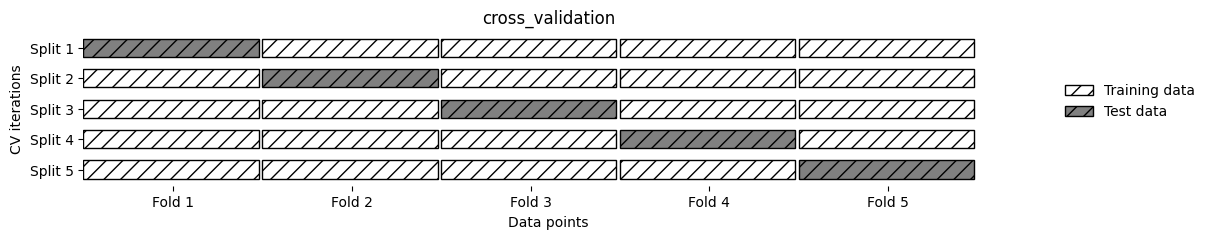

In [4]:
mglearn.plots.plot_cross_validation()

### **1.1. Cross-Validation in scikit-learn**

Cross-validation is implemented in scikit-learn using the cross_val_score func
tion from the model_selection module. The parameters of the cross_val_score
function are the model we want to evaluate, the training data, and the ground-truth labels. Let’s evaluate LogisticRegression on the iris dataset:

In [5]:
from sklearn.model_selection import cross_val_score
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression

iris = load_iris()
logreg = LogisticRegression(max_iter=1000)

scores = cross_val_score(logreg, iris.data, iris.target, cv=5)
print("Cross-validation scores: {}".format(scores))

Cross-validation scores: [0.96666667 1.         0.93333333 0.96666667 1.        ]


By default, cross_val_score performs five-fold stratified cross-validation for classification, returning five accuracy values. A common way to summarize the cross-validation accuracy is to compute the mean:

In [6]:
print("Average cross-validation score: {:.2f}".format(scores.mean()))

Average cross-validation score: 0.97


Based on the mean cross-validation score, the model demonstrates an expected average accuracy of approximately 97%. However, a closer examination of the individual results across all five folds reveals a noticeable variance, with performance fluctuating between 90% and 100%. This spread suggests that the model is quite sensitive to the specific data splits used during training; although, we must also acknowledge that this fluctuation could simply be a byproduct of working with a relatively small dataset.

### **1.2. Benefits of Cross-Validation**

When evaluating model performance, relying on a single train-test split leaves us vulnerable to the randomness of data distribution. A "lucky" split might place all difficult cases in the training set, artificially inflating our test accuracy, while an "unlucky" split could yield unrealistically low scores. Cross-validation effectively mitigates this risk by ensuring every single data point serves as part of the test set exactly once across its multiple folds. This forces the model to prove its ability to generalize across the entire dataset rather than a potentially biased subset. Furthermore, by observing the variance in accuracy across these multiple splits, we gain valuable insight into the model's sensitivity to the training data, allowing us to better anticipate its best- and worst-case performance in real-world scenarios.

Beyond stability, cross-validation also allows for a much more efficient utilization of our available data. While a standard single split typically reserves only 75% of the data for training, methods like 5-fold or 10-fold cross-validation allow us to leverage 80% to 90% of our data to fit the model in each iteration, which generally leads to improved accuracy. We must, however, weigh these benefits against the primary drawback of increased computational expense, as training k separate models naturally takes roughly k times longer. Ultimately, it is crucial to remember that cross-validation is strictly an evaluation technique designed to measure an algorithm's generalization capabilities on a specific dataset; it does not output a finalized model for deployment, but rather provides a rigorous assessment of our chosen approach.

### **1.3. Stratified k-Fold Cross-Validation and Other Strategies**

Splitting the dataset into k folds by starting with the first one-k-th part of the data, as described in the previous section, might not always be a good idea. For example, let’s have a look at the iris dataset:

In [7]:
from sklearn.datasets import load_iris
iris = load_iris()
print("Iris labels:\n{}".format(iris.target))

Iris labels:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


As you can see, the first third of the data is the class 0, the second third is the class 1, and the last third is the class 2. Imagine doing three-fold cross-validation on this dataset. The first fold would be only class 0, so in the first split of the data, the test set would be only class 0, and the training set would be only classes 1 and 2. As the classes in training and test sets would be different for all three splits, the three-fold cross-validation accuracy would be zero on this dataset. That is not very helpful, as we can do much better than 0% accuracy on iris.

As the simple $k$-fold strategy fails here, scikit-learn does not use it for classification, but rather uses **stratified $k$-fold cross-validation**. In stratified cross-validation, we split the data such that the proportions between classes are the same in each fold as they are in the whole dataset. The following figure illustrates this:

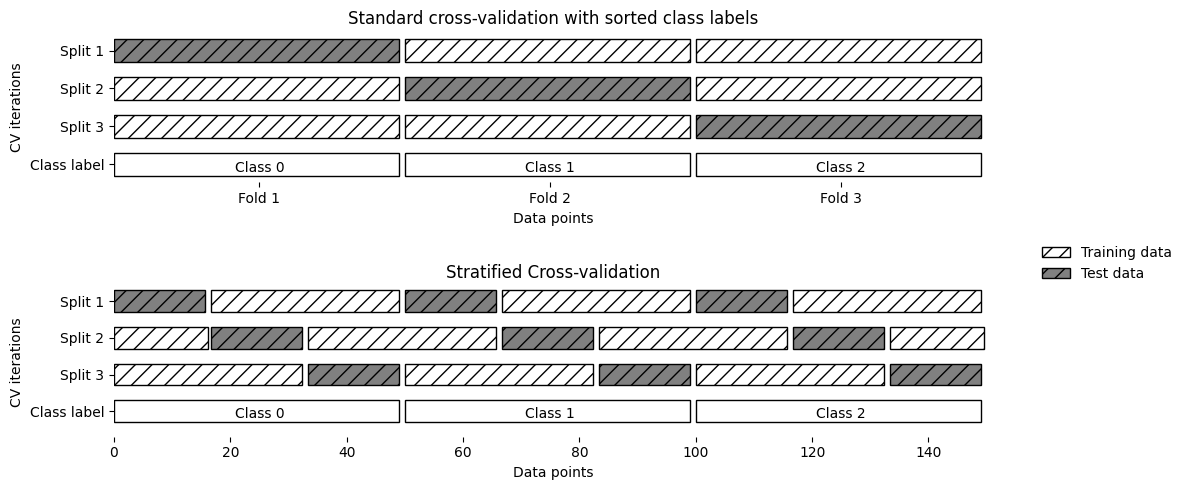

In [8]:
mglearn.plots.plot_stratified_cross_validation()

To illustrate, if our dataset has a class distribution of 90% class A and 10% class B, stratified cross-validation ensures that this exact 90:10 ratio is strictly maintained across every single fold.

When evaluating a classification model, opting for stratified k-fold over standard k-fold cross-validation is highly recommended. It provides a much more robust and reliable estimate of the model's generalization capabilities. For instance, with a 10% minority class, standard k-fold could easily—by sheer chance—generate a test fold containing exclusively class A samples. Evaluating our classifier on such a skewed fold wouldn't yield any meaningful insight into its true overall performance.

It is also worth noting that for regression tasks, scikit-learn applies standard k-fold cross-validation by default. While we could theoretically attempt to structure the folds to be perfectly representative of the continuous target values, standard k-fold generally remains the accepted practice for these scenarios.

### **1.4. More Control over Cross-Validation**

As we touched on earlier, while we can simply pass an integer to the cv parameter in cross_val_score to adjust the number of folds, scikit-learn actually offers a much finer degree of control over the data-splitting mechanism.

For the majority of our experiments, the default settings—standard k-fold for regression and stratified k-fold for classification—perform remarkably well. However, in certain analytical scenarios, we might need a more customized strategy. For instance, if our objective is to strictly replicate a previous study's methodology that applied standard k-fold to a classification dataset, we must bypass those default behaviors.

To achieve this level of customization, we can provide a specific cross-validation splitter object to the cv parameter. Practically, this means we first need to import the KFold class directly from the model_selection module, and then instantiate it with our precise desired number of folds.

In [9]:
from sklearn.model_selection import KFold
kfold = KFold(n_splits=5)
print("Cross-validation scores:\n{}".format(
    cross_val_score(logreg, iris.data, iris.target, cv=kfold)))

Cross-validation scores:
[1.         1.         0.86666667 0.93333333 0.83333333]


Notice that the scores are more variable than with stratified $k$-fold, because without stratification some folds may have unbalanced class distributions. Now let's see what happens with 3-fold KFold on the iris dataset where the labels are sorted:

In [10]:
kfold = KFold(n_splits=3)
print("Cross-validation scores:\n{}".format(
    cross_val_score(logreg, iris.data, iris.target, cv=kfold)))

Cross-validation scores:
[0. 0. 0.]


It is important to keep in mind that due to the inherent label ordering in the Iris dataset, a standard split might result in each fold containing only a single class. Consequently, the model fails to learn any meaningful patterns. An effective alternative to using stratified folds is to simply shuffle the data beforehand, which breaks this ordered sequence.

We can easily implement this by setting the shuffle parameter in the KFold function to True. Furthermore, to maintain academic rigor and reproducibility, we must also define a random_state during this process. Without it, functions like cross_val_score will generate different data splits on every single execution. While this variability isn't inherently incorrect, it can lead to inconsistent and unexpected evaluations. Ultimately, by applying this shuffling technique prior to splitting the data, we can achieve significantly more reliable and improved outcomes.

In [11]:
kfold = KFold(n_splits=3, shuffle=True, random_state=0)
print("Cross-validation scores:\n{}".format(
    cross_val_score(logreg, iris.data, iris.target, cv=kfold)))

Cross-validation scores:
[0.98 0.96 0.96]


Shuffling the data before splitting it yields a much better result -- all folds now achieve above 96% accuracy, because each fold contains a balanced mix of all three classes.


### **1.5. Leave-One-Out Cross-Validation**

Another frequently used cross-validation method is leave-one-out. You can think of leave-one-out cross-validation as k-fold cross-validation where each fold is a single sample. For each split, you pick a single data point to be the test set. This can be very time consuming, particularly for large datasets, but sometimes provides better estimates on small datasets:

In [12]:
from sklearn.model_selection import LeaveOneOut
loo = LeaveOneOut()
scores = cross_val_score(logreg, iris.data, iris.target, cv=loo)
print("Number of cv iterations: ", len(scores))
print("Mean accuracy: {:.2f}".format(scores.mean()))

Number of cv iterations:  150
Mean accuracy: 0.97


Since the iris dataset has 150 samples, we get 150 iterations -- one model per sample. The mean accuracy of 0.97 is consistent with the five-fold cross-validation estimate. LOO uses the maximum possible training set size ($n - 1$ samples per iteration), which is its main advantage. However, it is computationally expensive: for this small dataset we trained 150 models instead of 5.

### **1.6. Shuffle-Split Cross-Validation**

Alternatively, if we require a more adaptable strategy for our model evaluation, we can utilize shuffle-split cross-validation. The logic behind this method is quite straightforward: for every split, the algorithm randomly samples a designated train_size of data points for the training set, alongside a separate, non-overlapping test_size for the testing set. This entire sampling process is then repeated for a specified number of iterations, denoted as n_iter.

For context, as illustrated in Figure 5-3, imagine we have a dataset consisting of 10 data points. If we execute four iterations of this split, a single iteration might allocate 5 points strictly for training and 2 for testing. From a practical implementation standpoint, this is highly convenient—we have the flexibility to define these parameters using either exact integers for absolute data counts, or floating-point numbers if we prefer to configure them as fractions of our total dataset.

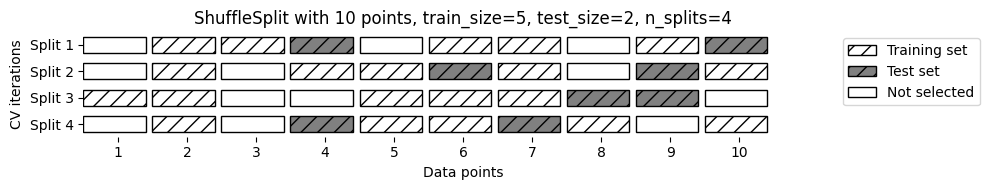

In [13]:
mglearn.plots.plot_shuffle_split()

The following code splits the dataset into 50% training set and 50% test set for 10 iterations. Unlike $k$-fold where each sample appears in exactly one test fold, ShuffleSplit can include the same sample in multiple test sets (or none at all):

In [14]:
from sklearn.model_selection import ShuffleSplit
shuffle_split = ShuffleSplit(test_size=.5, train_size=.5, n_splits=10)
scores = cross_val_score(logreg, iris.data, iris.target, cv=shuffle_split)
print("Cross-validation scores:\n{}".format(scores))

Cross-validation scores:
[0.94666667 0.94666667 0.98666667 0.97333333 0.97333333 0.97333333
 0.97333333 0.96       0.97333333 0.94666667]


Shuffle-split cross-validation allows for control over the number of iterations independently of the training and test sizes, which can sometimes be helpful. It also allows for using only part of the data in each iteration, by providing train_size and test_size settings that don't add up to one. Subsampling the data in this way can be useful for experimenting with large datasets. There is also a stratified variant of ShuffleSplit, aptly named StratifiedShuffleSplit, which can provide more reliable results for classification tasks.

### **1.7. Cross-Validation with Groups**

A common challenge in cross-validation arises when a dataset contains highly related groups, such as multiple facial images of the same individual collected for an emotion recognition system. If we apply standard stratified cross-validation, we risk data leakage because images of the same person might end up in both the training and testing sets. This overlap makes it artificially easier for the classifier to predict emotions on familiar faces, thereby failing to accurately reflect its true ability to generalize to completely new, unseen individuals. To properly evaluate how well the model will perform in real-world scenarios, it is crucial to guarantee that the training and test sets contain entirely different people.

To address this structural issue, we can implement GroupKFold, a technique that utilizes a specific 'groups' array to ensure that related data points are never split across the train-test boundary. This approach is highly relevant across various fields, such as medical applications that involve multiple samples per patient, or speech recognition systems utilizing multiple recordings per speaker. It is important to note that this groups array simply acts as an indicator for data splitting and should not be confused with the target class labels. For instance, if we have a synthetic dataset of 12 points representing four distinct patients, the groups array dictates exactly which samples belong to which patient, guaranteeing that all data points from any single patient remain strictly grouped together during evaluation.

In [15]:
from sklearn.model_selection import GroupKFold
# create synthetic dataset
X, y = make_blobs(n_samples=12, random_state=0)
# assume the first three samples belong to the same group,
# then the next four, etc.
groups = [0, 0, 0, 1, 1, 1, 1, 2, 2, 3, 3, 3]
scores = cross_val_score(logreg, X, y, groups=groups, cv=GroupKFold(n_splits=3))
print("Cross-validation scores:\n{}".format(scores))

Cross-validation scores:
[0.75       0.6        0.66666667]


The samples don't need to be ordered by group; we just did this for illustration purposes. As you can see, for each split, each group is either entirely in the training set or entirely in the test set. The splits are visualized in the following figure:

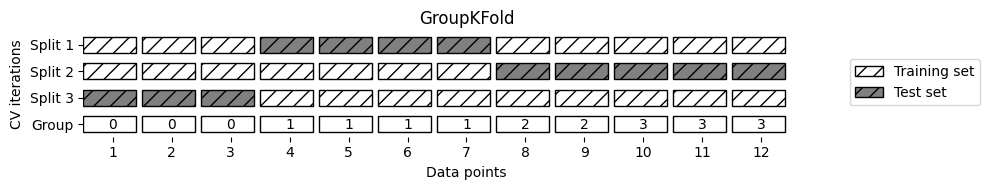

In [16]:
mglearn.plots.plot_group_kfold()

This visualization confirms the key property of GroupKFold: no group is ever split across training and test sets. This is essential when data points within a group are correlated -- for example, multiple images of the same patient's tissue, multiple recordings from the same speaker, or multiple time points from the same subject.

There are more splitting strategies for cross-validation in scikit-learn (you can find these in the scikit-learn user guide). However, the standard KFold, StratifiedKFold, and GroupKFold are by far the most commonly used ones.

## **2. Grid Search**

Now that we understand how to evaluate a model's generalization, we can focus on optimizing its performance by carefully tuning its parameters, a crucial but complex step for almost any dataset. While it is essential to comprehend what these parameters actually control before adjusting them, scikit-learn significantly simplifies this process through standard methods like grid search, which systematically evaluates all possible parameter combinations. For instance, when configuring a kernel SVM with an RBF kernel via the SVC class, we primarily adjust the kernel bandwidth (gamma) and the regularization parameter (C). If we decide to test six specific values for both C and gamma (such as 0.001, 0.01, 0.1, 1, 10, and 100), the grid search approach will automatically generate and evaluate a comprehensive grid consisting of all 36 possible parameter combinations to identify the most effective setup.

### **2.1. Simple Grid Search**

We can implement a simple grid search just as for loops over the two parameters, training and evaluating a classifier for each combination:

In [17]:
# naive grid search implementation
from sklearn.svm import SVC
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, random_state=0)
print("Size of training set: {}   size of test set: {}".format(
    X_train.shape[0], X_test.shape[0]))

best_score = 0

for gamma in [0.001, 0.01, 0.1, 1, 10, 100]:
    for C in [0.001, 0.01, 0.1, 1, 10, 100]:
        # for each combination of parameters, train an SVC
        svm = SVC(gamma=gamma, C=C)
        svm.fit(X_train, y_train)
        # evaluate the SVC on the test set
        score = svm.score(X_test, y_test)
        # if we got a better score, store the score and parameters
        if score > best_score:
            best_score = score
            best_parameters = {'C': C, 'gamma': gamma}

print("Best score: {:.2f}".format(best_score))
print("Best parameters: {}".format(best_parameters))

Size of training set: 112   size of test set: 38
Best score: 0.97
Best parameters: {'C': 100, 'gamma': 0.001}


The grid search found that C=100 and gamma=0.001 achieves 97% accuracy on the test set. However, this score may be overly optimistic, for an important reason.

### **2.2. The Danger of Overfitting the Parameters and the Validation Set**

While we might be tempted to report our model's 97% accuracy, claiming this could be overly optimistic because tuning our parameters based on the test set effectively compromises its ability to act as an independent evaluator. Just as we initially separated our data to avoid bias, we cannot reliably predict how the model will perform on completely unseen data if the test set was already used to influence its current parameters. To ensure our methodology remains strictly objective, the best way to resolve this is by dividing the dataset into three distinct parts: a training set to initially build the model, a validation set to fine-tune the parameters, and a strictly untouched test set reserved solely for the final performance assessment.

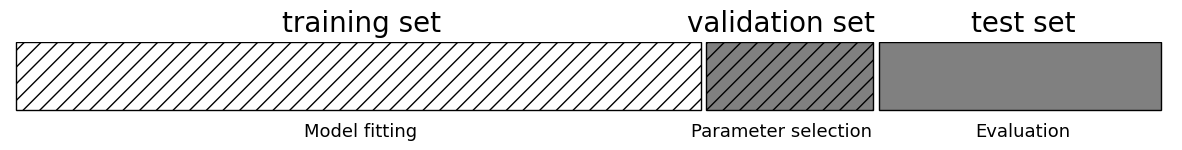

In [18]:
mglearn.plots.plot_threefold_split()

After selecting the best parameters using the validation set, we can rebuild a model using the parameter settings we found, but now training on both the training data and the validation data. This way, we can use as much data as possible to build our model. This leads to the following implementation:

In [19]:
from sklearn.svm import SVC
# split data into train+validation set and test set
X_trainval, X_test, y_trainval, y_test = train_test_split(
    iris.data, iris.target, random_state=0)
# split train+validation set into training and validation sets
X_train, X_valid, y_train, y_valid = train_test_split(
    X_trainval, y_trainval, random_state=1)
print("Size of training set: {}   size of validation set: {}"
      "   size of test set: {}\n".format(
    X_train.shape[0], X_valid.shape[0], X_test.shape[0]))

best_score = 0

for gamma in [0.001, 0.01, 0.1, 1, 10, 100]:
    for C in [0.001, 0.01, 0.1, 1, 10, 100]:
        # for each combination of parameters, train an SVC
        svm = SVC(gamma=gamma, C=C)
        svm.fit(X_train, y_train)
        # evaluate the SVC on the validation set
        score = svm.score(X_valid, y_valid)
        # if we got a better score, store the score and parameters
        if score > best_score:
            best_score = score
            best_parameters = {'C': C, 'gamma': gamma}

# rebuild a model on the combined training and validation set,
# and evaluate it on the test set
svm = SVC(**best_parameters)
svm.fit(X_trainval, y_trainval)
test_score = svm.score(X_test, y_test)
print("Best score on validation set: {:.2f}".format(best_score))
print("Best parameters: ", best_parameters)
print("Test set score with best parameters: {:.2f}".format(test_score))

Size of training set: 84   size of validation set: 28   size of test set: 38

Best score on validation set: 0.96
Best parameters:  {'C': 10, 'gamma': 0.001}
Test set score with best parameters: 0.92


Although our validation score slightly decreased to 96%—likely because the double split reduced our training data—our true generalization capability is reflected by the 92% test score, meaning we can realistically claim only a 92% accuracy on unseen data rather than our initial 97% estimate. This discrepancy perfectly illustrates the fundamental importance of strictly isolating the training, validation, and test sets in machine learning practice. To prevent information 'leakage' that inflates our results, we must conduct all exploratory analysis and model selection exclusively on the combination of training and validation sets. The test set must be rigorously reserved for the final evaluation alone; otherwise, even a seemingly harmless action like evaluating multiple models on the test set to pick the best one will compromise its integrity and yield a misleadingly optimistic estimate of the model's actual performance.

### **2.3. Grid Search with Cross-Validation**

While the conventional method of partitioning data into training, validation, and test sets is workable and widely used, it remains highly sensitive to the specific way the data is split. This sensitivity is evident when comparing our results: the recent GridSearchCV output identified {'C': 10, 'gamma': 0.001} as the optimal parameters, whereas our previous approach selected {'C': 100, 'gamma': 0.001}. To achieve a more reliable estimate of generalization performance, rather than relying on a single train-validation split, we can employ cross-validation to systematically evaluate each parameter combination. This improved approach can be implemented as follows:

In [20]:
best_score = 0

for gamma in [0.001, 0.01, 0.1, 1, 10, 100]:
    for C in [0.001, 0.01, 0.1, 1, 10, 100]:
        # for each combination of parameters, train an SVC
        svm = SVC(gamma=gamma, C=C)
        # perform cross-validation
        scores = cross_val_score(svm, X_trainval, y_trainval, cv=5)
        # compute mean cross-validation accuracy
        score = np.mean(scores)
        # if we got a better score, store the score and parameters
        if score > best_score:
            best_score = score
            best_parameters = {'C': C, 'gamma': gamma}

# rebuild a model on the combined training and validation set
svm = SVC(**best_parameters)
svm.fit(X_trainval, y_trainval)

SVC(C=10, gamma=0.1)

To evaluate the accuracy of the SVM using a particular setting of $C$ and $\gamma$ using five-fold cross-validation, we need to train $36 \times 5 = 180$ models. As you can imagine, the main downside of the use of cross-validation is the time it takes to train all these models.

The following visualization illustrates how the best parameter setting is selected. For each parameter setting, five accuracy values are computed (one for each split), then the mean validation accuracy is computed. The parameters with the highest mean validation accuracy are chosen:

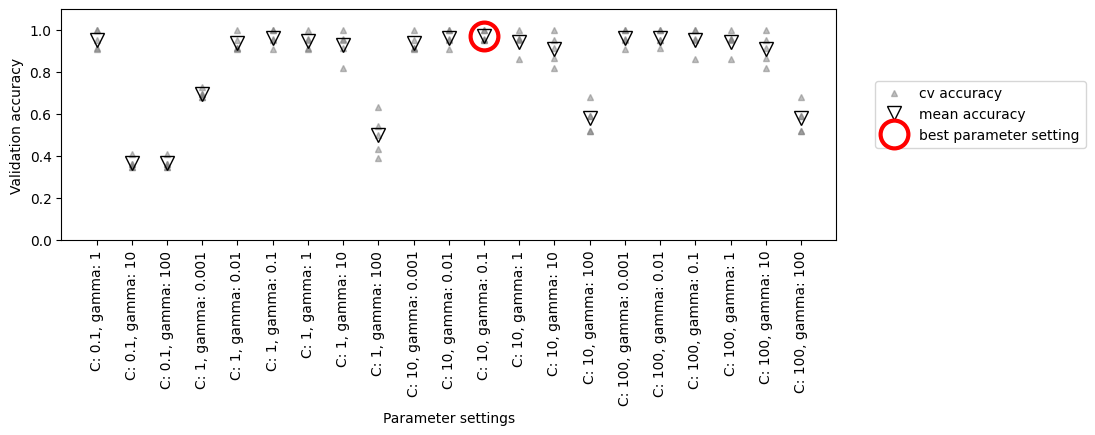

In [21]:
mglearn.plots.plot_cross_val_selection()

The overall process of splitting the data, running the grid search, and evaluating the final parameters is illustrated in the following figure:

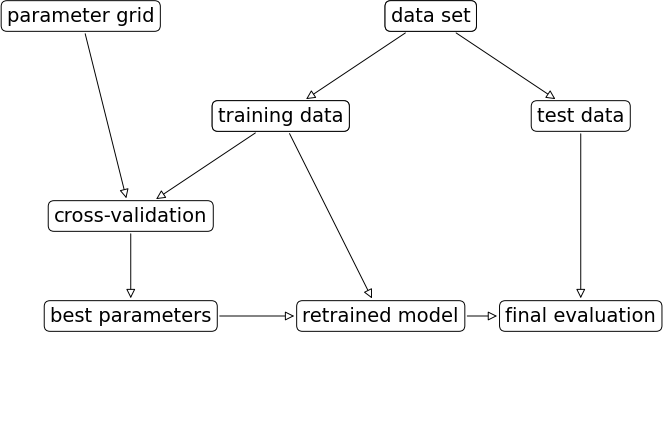

In [22]:
mglearn.plots.plot_grid_search_overview()

Because grid search with cross-validation is such a commonly used method to adjust parameters, scikit-learn provides the GridSearchCV class, which implements it in the form of an estimator. To use it, you first specify the parameters you want to search over using a dictionary. The keys are parameter names and the values are lists of settings to try. Trying the values 0.001, 0.01, 0.1, 1, 10, and 100 for $C$ and $\gamma$ translates to the following dictionary:

In [23]:
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100],
              'gamma': [0.001, 0.01, 0.1, 1, 10, 100]}
print("Parameter grid:\n{}".format(param_grid))

Parameter grid:
{'C': [0.001, 0.01, 0.1, 1, 10, 100], 'gamma': [0.001, 0.01, 0.1, 1, 10, 100]}


We can now instantiate the GridSearchCV class with the model (SVC), the parameter grid to search (param_grid), and the cross-validation strategy we want to use (say, five-fold stratified cross-validation). We still need to split the data into a training and a test set, to avoid overfitting the parameters:

In [24]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
grid_search = GridSearchCV(SVC(), param_grid, cv=5)

X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, random_state=0)

The grid_search object behaves just like a classifier; we can call the standard methods fit, predict, and score on it. However, when we call fit, it will run cross-validation for each combination of parameters we specified in param_grid. Fitting the GridSearchCV object not only searches for the best parameters, but also automatically fits a new model on the whole training dataset with the parameters that yielded the best cross-validation performance:

In [25]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100],
                         'gamma': [0.001, 0.01, 0.1, 1, 10, 100]})

To evaluate how well the best found parameters generalize, we can call score on the test set:

In [26]:
print("Test set score: {:.2f}".format(grid_search.score(X_test, y_test)))

Test set score: 0.97


Choosing the parameters using cross-validation, we actually found a model that achieves 97% accuracy on the test set. The important thing here is that we did not use the test set to choose the parameters. The parameters that were found are stored in the best_params_ attribute, and the best cross-validation accuracy (the mean accuracy over the different splits for this parameter setting) is stored in best_score_:

In [27]:
print("Best parameters: {}".format(grid_search.best_params_))
print("Best cross-validation score: {:.2f}".format(grid_search.best_score_))

Best parameters: {'C': 10, 'gamma': 0.1}
Best cross-validation score: 0.97


Furthermore, it is crucial to distinguish the best_score_ attribute from the model's actual generalization performance, which is evaluated using the score method on our hold-out test set. To clarify, invoking the score method—or analyzing the outputs of the predict function—evaluates a model that has been fully trained on the entire training dataset. Conversely, the best_score_ attribute specifically represents the mean cross-validation accuracy, which is calculated exclusively during the training phase.

Beyond evaluating performance metrics, we often need to examine the underlying model itself, such as when analyzing model coefficients or extracting feature importances. In such cases, we can retrieve the optimal model—fitted on the full training set using the best-identified hyperparameters—by accessing the best_estimator_ attribute:

In [28]:
print("Best estimator:\n{}".format(grid_search.best_estimator_))

Best estimator:
SVC(C=10, gamma=0.1)


### **2.4. Analyzing the Result of Cross-Validation**

Visualizing cross-validation outcomes is highly beneficial for understanding how hyperparameter tuning impacts a model's generalization capabilities. Given that grid searches demand significant computational resources, a practical strategy is to initiate the process with a smaller, broader grid. Once we evaluate these preliminary results, we can strategically expand our search space if necessary. All comprehensive details regarding the search process are logged within the cv_results_ attribute in a dictionary format. Because it contains such an extensive amount of information—as illustrated in the output below—the most effective way to analyze this data is by converting it into a pandas DataFrame first.

In [29]:
import pandas as pd
# convert to DataFrame
results = pd.DataFrame(grid_search.cv_results_)
# show the first 5 rows
display(results.head())

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_gamma,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.004214,0.001026,0.002273,0.001539,0.001,0.001,"{'C': 0.001, 'gamma': 0.001}",0.347826,0.347826,0.363636,0.363636,0.409091,0.366403,0.022485,22
1,0.004773,0.002042,0.003463,0.002015,0.001,0.010,"{'C': 0.001, 'gamma': 0.01}",0.347826,0.347826,0.363636,0.363636,0.409091,0.366403,0.022485,22
2,0.005286,0.001095,0.003942,0.002225,0.001,0.100,"{'C': 0.001, 'gamma': 0.1}",0.347826,0.347826,0.363636,0.363636,0.409091,0.366403,0.022485,22
3,0.004411,0.001527,0.003084,0.001644,0.001,1.000,"{'C': 0.001, 'gamma': 1}",0.347826,0.347826,0.363636,0.363636,0.409091,0.366403,0.022485,22
4,0.003833,0.002048,0.001945,0.000917,0.001,10.000,"{'C': 0.001, 'gamma': 10}",0.347826,0.347826,0.363636,0.363636,0.409091,0.366403,0.022485,22


Each row in results corresponds to one particular parameter setting. For each setting, the results of all cross-validation splits are recorded, as well as the mean and standard deviation over all splits. As we were searching a two-dimensional grid of parameters (C and gamma), this is best visualized as a heat map. First we extract the mean validation scores, then we reshape the scores so that the axes correspond to C and gamma:

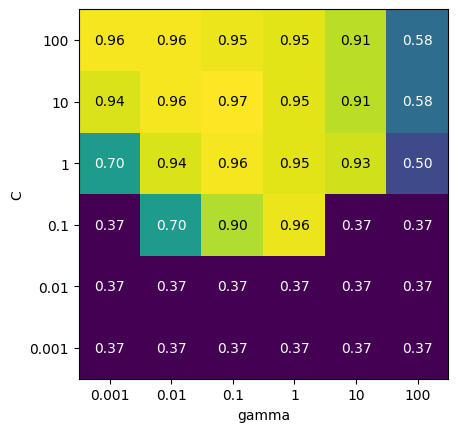

In [30]:
scores = np.array(results.mean_test_score).astype(float).reshape(6, 6)

# plot the mean cross-validation scores
mglearn.tools.heatmap(scores, xlabel='gamma', xticklabels=param_grid['gamma'],
                      ylabel='C', yticklabels=param_grid['C'], cmap="viridis")

Each point in the heat map corresponds to one run of cross-validation, with a particular parameter setting. The color encodes the cross-validation accuracy, with light colors meaning high accuracy and dark colors meaning low accuracy. You can see that SVC is very sensitive to the setting of the parameters. For many of the parameter settings, the accuracy is around 40%, which is quite bad; for other settings the accuracy is around 96%. We can take away from this plot several things. First, the parameters we adjusted are very important for obtaining good performance. Both parameters (C and gamma) matter a lot, as adjusting them can change the accuracy from 40% to 96%. Additionally, the ranges we picked for the parameters are ranges in which we see significant changes in the outcome. It’s also important to note that the ranges for the parameters are large enough: the optimum values for each parameter are not on
the edges of the plot.

Now let's look at some plots where the result is less ideal, because the search ranges were not chosen properly:

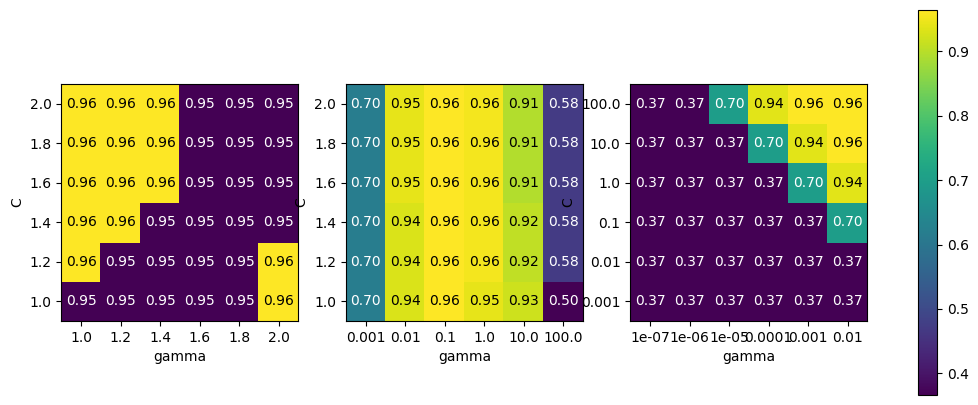

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(13, 5))

param_grid_linear = {'C': np.linspace(1, 2, 6),
                     'gamma': np.linspace(1, 2, 6)}

param_grid_one_log = {'C': np.linspace(1, 2, 6),
                      'gamma': np.logspace(-3, 2, 6)}

param_grid_range = {'C': np.logspace(-3, 2, 6),
                    'gamma': np.logspace(-7, -2, 6)}

for param_grid, ax in zip([param_grid_linear, param_grid_one_log,
                           param_grid_range], axes):
    grid_search = GridSearchCV(SVC(), param_grid, cv=5)
    grid_search.fit(X_train, y_train)
    scores = np.array(grid_search.cv_results_['mean_test_score']).astype(float).reshape(6, 6)

    # plot the mean cross-validation scores
    scores_image = mglearn.tools.heatmap(
        scores, xlabel='gamma', ylabel='C', xticklabels=param_grid['gamma'],
        yticklabels=param_grid['C'], cmap="viridis", ax=ax)

plt.colorbar(scores_image, ax=axes.tolist())

When evaluating parameter grid visualizations for hyperparameter tuning, different heatmap patterns provide distinct insights into parameter importance and search space appropriateness. A uniform plot often indicates improper scaling of parameters like C and gamma, or overall parameter unimportance, highlighting the value of testing extreme values initially. Conversely, a vertical stripe pattern suggests that only one parameter—such as gamma—is affecting the model, rendering the other either uninteresting or unimportant in that specific range. If the plot shows changes across both parameters but the optimal setting lies on a boundary, it strongly implies the true optimum might exist beyond the current search space, prompting a shift in the grid range to include new values while excluding uninformative regions. Finally, while iteratively tuning the parameter grid based on cross-validation scores is an effective exploration strategy, it is crucial to never evaluate these different ranges on the final test set, reserving that data strictly for the single, final model assessment.

### **2.5. Search over Spaces That Are Not Grids**

Exhaustively testing every parameter combination using GridSearchCV can be computationally inefficient when dealing with conditional parameters, such as in an SVC model where the gamma parameter is essential for an 'rbf' kernel but completely irrelevant for a 'linear' one. Evaluating these inapplicable combinations simply wastes processing time and resources. To effectively resolve this, GridSearchCV allows the param_grid to be structured as a list of dictionaries, enabling you to define independent, logically grouped parameter grids that are only executed when their specific model conditions are met.

In [32]:
param_grid = [{'kernel': ['rbf'],
               'C': [0.001, 0.01, 0.1, 1, 10, 100],
               'gamma': [0.001, 0.01, 0.1, 1, 10, 100]},
              {'kernel': ['linear'],
               'C': [0.001, 0.01, 0.1, 1, 10, 100]}]
print("List of grids:\n{}".format(param_grid))

List of grids:
[{'kernel': ['rbf'], 'C': [0.001, 0.01, 0.1, 1, 10, 100], 'gamma': [0.001, 0.01, 0.1, 1, 10, 100]}, {'kernel': ['linear'], 'C': [0.001, 0.01, 0.1, 1, 10, 100]}]


In the first grid, the kernel parameter is always set to 'rbf' (not that the entry for kernel is a list of length one), and both the C and gamma parameters are varied. In the second grid, the kernel parameter is always set to linear, and only C is varied. Now let’s apply this more complex parameter search:

In [33]:
grid_search = GridSearchCV(SVC(), param_grid, cv=5)
grid_search.fit(X_train, y_train)
print("Best parameters: {}".format(grid_search.best_params_))
print("Best cross-validation score: {:.2f}".format(grid_search.best_score_))

Best parameters: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
Best cross-validation score: 0.97


The best model uses the RBF kernel with $C = 10$ and $\gamma = 0.1$. Let's look at the cv_results_ to confirm that the linear kernel entries correctly have NaN for gamma:

In [34]:
results = pd.DataFrame(grid_search.cv_results_)
# we display the transposed table so that it better fits on the page:
display(results.T)

,0,1,2,3,4,5,6,7,8,9,...,32,33,34,35,36,37,38,39,40,41
mean_fit_time,0.000942,0.00083,0.000818,0.000809,0.000808,0.000905,0.000792,0.000803,0.000804,0.000823,...,0.000652,0.000743,0.000927,0.001052,0.000789,0.000722,0.000691,0.000635,0.000635,0.000671
std_fit_time,0.000137,0.000022,0.000019,0.000009,0.000014,0.000013,0.000016,0.000009,0.000016,0.000018,...,0.000034,0.000027,0.000011,0.000027,0.000036,0.000014,0.000031,0.00001,0.000018,0.000025
mean_score_time,0.000617,0.000562,0.000547,0.00056,0.000536,0.00058,0.00054,0.000531,0.000568,0.000548,...,0.000541,0.000529,0.00054,0.000579,0.000506,0.000519,0.000509,0.000479,0.000484,0.000497
std_score_time,0.000065,0.000019,0.000008,0.000028,0.000012,0.000022,0.000016,0.000013,0.000043,0.000019,...,0.000103,0.000021,0.000012,0.000023,0.000015,0.000039,0.000011,0.000015,0.000029,0.00003
param_C,0.001,0.001,0.001,0.001,0.001,0.001,0.01,0.01,0.01,0.01,...,100.0,100.0,100.0,100.0,0.001,0.01,0.1,1.0,10.0,100.0
param_gamma,0.001,0.01,0.1,1.0,10.0,100.0,0.001,0.01,0.1,1.0,...,0.1,1.0,10.0,100.0,NaN,NaN,NaN,NaN,NaN,NaN
param_kernel,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,...,rbf,rbf,rbf,rbf,linear,linear,linear,linear,linear,linear
params,"{'C': 0.001, 'gamma': 0.001, 'kernel': 'rbf'}","{'C': 0.001, 'gamma': 0.01, 'kernel': 'rbf'}","{'C': 0.001, 'gamma': 0.1, 'kernel': 'rbf'}","{'C': 0.001, 'gamma': 1, 'kernel': 'rbf'}","{'C': 0.001, 'gamma': 10, 'kernel': 'rbf'}","{'C': 0.001, 'gamma': 100, 'kernel': 'rbf'}","{'C': 0.01, 'gamma': 0.001, 'kernel': 'rbf'}","{'C': 0.01, 'gamma': 0.01, 'kernel': 'rbf'}","{'C': 0.01, 'gamma': 0.1, 'kernel': 'rbf'}","{'C': 0.01, 'gamma': 1, 'kernel': 'rbf'}",...,"{'C': 100, 'gamma': 0.1, 'kernel': 'rbf'}","{'C': 100, 'gamma': 1, 'kernel': 'rbf'}","{'C': 100, 'gamma': 10, 'kernel': 'rbf'}","{'C': 100, 'gamma': 100, 'kernel': 'rbf'}","{'C': 0.001, 'kernel': 'linear'}","{'C': 0.01, 'kernel': 'linear'}","{'C': 0.1, 'kernel': 'linear'}","{'C': 1, 'kernel': 'linear'}","{'C': 10, 'kernel': 'linear'}","{'C': 100, 'kernel': 'linear'}"
split0_test_score,0.347826,0.347826,0.347826,0.347826,0.347826,0.347826,0.347826,0.347826,0.347826,0.347826,...,1.0,0.956522,0.869565,0.521739,0.347826,0.869565,1.0,1.0,1.0,0.956522
split1_test_score,0.347826,0.347826,0.347826,0.347826,0.347826,0.347826,0.347826,0.347826,0.347826,0.347826,...,0.956522,0.956522,0.913043,0.521739,0.347826,0.869565,0.913043,0.956522,1.0,0.956522


The results table shows all 42 parameter combinations. For the first 36 rows (RBF kernel), both param_C and param_gamma have values. For the last 6 rows (linear kernel), param_gamma is NaN, confirming that only $C$ was varied when the kernel is linear. This is more efficient than testing all $6 \times 6 \times 2 = 72$ combinations, because we avoided the 36 meaningless combinations of gamma with the linear kernel.

### **2.6. Using different cross-validation strategies with grid search**
Similarly to cross_val_score, GridSearchCV uses stratified k-fold cross-validation by default for classification, and k-fold cross-validation for regression. In particular, to get only a single split into a training and a validation set, you can use ShuffleSplit or StratifiedShuffleSplit with n_iter=1. This might be helpful for very large datasets, or very slow models.

### **2.7. Nested Cross-Validation**

While transitioning from a simple three-way split to performing cross-validation on a dedicated training set offers more robustness, relying on a single train-test split within GridSearchCV can still lead to unstable results due to a high dependency on that specific data partition. To mitigate this, we can implement nested cross-validation, which introduces an outer loop of data splits to complement the inner grid search; for every outer split, the system identifies the optimal parameters and evaluates them, ultimately producing a comprehensive list of scores rather than a single model or fixed parameter set. Although this method is rarely utilized for deploying final predictive models—given that its primary output is a generalization performance metric rather than a finalized estimator—it remains an invaluable tool for rigorously evaluating a model's efficacy on a specific dataset. In practice, this can be seamlessly implemented in scikit-learn by passing a GridSearchCV instance directly into the cross_val_score function.

Implementing nested cross-validation in scikit-learn is straightforward. We call cross_val_score with an instance of GridSearchCV as the model:

In [35]:
param_grid = [{'kernel': ['rbf'],
               'C': [0.001, 0.01, 0.1, 1, 10, 100],
               'gamma': [0.001, 0.01, 0.1, 1, 10, 100]},
              {'kernel': ['linear'],
               'C': [0.001, 0.01, 0.1, 1, 10, 100]}]

scores = cross_val_score(GridSearchCV(SVC(), param_grid, cv=5),
                         iris.data, iris.target, cv=5)
print("Cross-validation scores: ", scores)
print("Mean cross-validation score: {:.2f}".format(scores.mean()))

Cross-validation scores:  [0.96666667 1.         0.9        0.96666667 1.        ]
Mean cross-validation score: 0.97


The outcome of our nested cross-validation process indicates that the SVC model achieves a mean cross-validation accuracy of 98% on the Iris dataset; beyond this performance metric, the primary takeaway lies in the computational rigor of the method. By employing stratified five-fold cross-validation for both the inner and outer loops across 36 parameter combinations, we effectively trained 900 individual models—a result of the $36 \times 5 \times 5$ configuration—highlighting that while nested cross-validation is a robust evaluation tool, it is also a computationally intensive procedure. Although we utilized consistent cross-validation splitters for both loops in this instance, it is important to note that various strategies can be combined flexibly depending on the research needs. To better grasp the underlying logic of this single-line execution, one can conceptualize the process through a nested loop structure, as illustrated in the simplified implementation below.

In [36]:
def nested_cv(X, y, inner_cv, outer_cv, Classifier, parameter_grid):
    outer_scores = []
    # for each split of the data in the outer cross-validation
    for training_samples, test_samples in outer_cv.split(X, y):
        # find best parameter using inner cross-validation
        best_parms = {}
        best_score = -np.inf
        # iterate over parameters
        for parameters in parameter_grid:
            # accumulate score over inner splits
            cv_scores = []
            # iterate over inner cross-validation
            for inner_train, inner_test in inner_cv.split(
                    X[training_samples], y[training_samples]):
                # build classifier given parameters and training data
                clf = Classifier(**parameters)
                clf.fit(X[inner_train], y[inner_train])
                # evaluate on inner test set
                score = clf.score(X[inner_test], y[inner_test])
                cv_scores.append(score)
            # compute mean score over inner folds
            mean_score = np.mean(cv_scores)
            if mean_score > best_score:
                best_score = mean_score
                best_params = parameters
        # build classifier on best parameters using outer training set
        clf = Classifier(**best_params)
        clf.fit(X[training_samples], y[training_samples])
        # evaluate
        outer_scores.append(clf.score(X[test_samples], y[test_samples]))
    return np.array(outer_scores)

Now let's run this function on the iris dataset:

In [37]:
from sklearn.model_selection import ParameterGrid, StratifiedKFold
scores = nested_cv(iris.data, iris.target, StratifiedKFold(5),
                   StratifiedKFold(5), SVC, ParameterGrid(param_grid))
print("Cross-validation scores: {}".format(scores))

Cross-validation scores: [0.96666667 1.         0.96666667 0.96666667 1.        ]


The scores match the result from cross_val_score(GridSearchCV(...)) above, confirming our understanding of the nested procedure.



### **2.8. Parallelizing Cross-Validation and Grid Search**

While conducting an extensive grid search on large-scale datasets can be computationally intensive, the process is inherently 'embarrassingly parallel,' allowing individual model evaluations to be executed independently across multiple CPU cores via the n_jobs parameter. By leveraging this parallelization, researchers can significantly accelerate the hyperparameter tuning process, although care must be taken to avoid nested parallel operations and to monitor memory overhead when handling massive models. Furthermore, for even more demanding workloads, one might consider scaling beyond a single machine by utilizing frameworks like IPython parallel or the spark-sklearn package, which facilitate distributed grid searches across established clusters, effectively overcoming the localized constraints of standard scikit-learn implementations.



## **3. Evaluation Metrics and Scoring**

While we have primarily relied on accuracy for classification and $R^2$ for regression to evaluate model performance, it is crucial to recognize that these represent only a fraction of the available metrics for assessing supervised learning outcomes. In a practical research or development context, these standard measurements may not align with the specific requirements of a given application, necessitating the careful selection of evaluation metrics that more accurately reflect the model's effectiveness during parameter tuning and final selection.

### **3.1. Keep the End Goal in Mind**

When selecting an evaluation metric, it is imperative to prioritize the ultimate objective of the application—often referred to as the business metric—since machine learning predictions typically serve as a foundation for broader decision-making processes. While our primary goal is to maximize positive business impact, such as improving safety or increasing revenue, directly assessing a model in a production environment is often risky or impractical during the early stages of development. Consequently, we must identify a suitable surrogate metric that is computationally feasible yet remains as closely aligned with the high-level business goal as possible. This approach ensures that model selection and parameter tuning are driven by the expected real-world consequences, even when we are limited to proxy evaluations like accuracy or precision before full-scale deployment.

### 3.2. Metrics for Binary Classification

When selecting an evaluation metric, it is imperative to prioritize the ultimate objective of the application—often referred to as the business metric—since machine learning predictions typically serve as a foundation for broader decision-making processes. While our primary goal is to maximize positive business impact, such as improving safety or increasing revenue, directly assessing a model in a production environment is often risky or impractical during the early stages of development. Consequently, we must identify a suitable surrogate metric that is computationally feasible yet remains as closely aligned with the high-level business goal as possible. This approach ensures that model selection and parameter tuning are driven by the expected real-world consequences, even when we are limited to proxy evaluations like accuracy or precision before full-scale deployment.



### **3.3. Kinds of Errors**

While accuracy is a standard metric, it often falls short in capturing the true performance of a predictive model, especially when the real-world consequences of specific errors—namely false positives (Type I errors) and false negatives (Type II errors)—diverge significantly. In a high-stakes scenario such as cancer screening, a false negative is potentially fatal as it results in a missed diagnosis, whereas a false positive merely leads to the inconvenience of additional testing, highlighting that not all mistakes carry equal weight. Consequently, rather than relying on a simple count of correct predictions, we must evaluate our models based on the specific risks and costs associated with each error type, whether those costs are measured in clinical outcomes or, in a commercial context, integrated into a financial framework to facilitate more informed decision-making.



### **3.4. Imbalanced Datasets**

In practical machine learning applications, such as click-through rate prediction, we frequently encounter imbalanced datasets where the 'negative' class significantly outweighs the 'positive' class—often at a ratio of 99 to 1. In such scenarios, relying solely on accuracy as a performance metric can be highly misleading; for instance, a naive model that consistently predicts 'no click' would technically achieve 99% accuracy without learning any meaningful patterns, making it indistinguishable from a genuinely high-performing model. Therefore, understanding the specific types of errors becomes crucial when dealing with these skewed distributions, as it allows us to evaluate the model's true predictive power beyond simple frequency. To demonstrate this challenge, we can simulate an imbalanced environment by restructuring the digits dataset into a 9:1 ratio, specifically isolating the digit '9' against all other classes.

In [38]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

digits = load_digits()
y = digits.target == 9

X_train, X_test, y_train, y_test = train_test_split(
    digits.data, y, random_state=0)

We can use the DummyClassifier to always predict the majority class (here "not nine") to see how uninformative accuracy can be:

In [39]:
from sklearn.dummy import DummyClassifier
dummy_majority = DummyClassifier(strategy='most_frequent').fit(X_train, y_train)
pred_most_frequent = dummy_majority.predict(X_test)
print("Unique predicted labels: {}".format(np.unique(pred_most_frequent)))
print("Test score: {:.2f}".format(dummy_majority.score(X_test, y_test)))

Unique predicted labels: [False]
Test score: 0.90


We obtained close to 90% accuracy without learning anything. This might seem striking, but think about it: with roughly 90% of data points being "not nine," always guessing the majority class automatically gets approx 0.90$ accuracy. Imagine someone telling you their model is 90% accurate -- depending on the problem, that might be possible by just predicting one class!

Let's compare this against using an actual classifier:

In [40]:
from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier(max_depth=2).fit(X_train, y_train)
pred_tree = tree.predict(X_test)
print("Test score: {:.2f}".format(tree.score(X_test, y_test)))

Test score: 0.92


According to accuracy, the DecisionTreeClassifier is only slightly better than the constant predictor (0.92 vs. 0.90). This could indicate either that something is wrong with how we used DecisionTreeClassifier, or that accuracy is in fact not a good measure here. For comparison purposes, let's evaluate two more classifiers:

In [41]:
from sklearn.linear_model import LogisticRegression

dummy = DummyClassifier(strategy='most_frequent').fit(X_train, y_train)
pred_dummy = dummy.predict(X_test)
print("dummy score: {:.2f}".format(dummy.score(X_test, y_test)))

logreg = LogisticRegression(C=0.1, max_iter=1000).fit(X_train, y_train)
pred_logreg = logreg.predict(X_test)
print("logreg score: {:.2f}".format(logreg.score(X_test, y_test)))

dummy score: 0.90
logreg score: 0.98


LogisticRegression produces very good results at 0.98, while the dummy classifier achieves 0.90 by always predicting the majority class. However, even 0.90 accuracy sounds impressive if you don't know the class distribution. The problem here is that accuracy alone is an inadequate measure for quantifying predictive performance in this imbalanced setting. We would like metrics that tell us how much better a model is than making "most frequent" predictions.

### **3.5. Confusion Matrices**

One of the most comprehensive ways to represent the result of evaluating binary classification is using confusion matrices. Let’s inspect the predictions of LogisticRegression from the previous section using the confusion_matrix function. We already stored the predictions on the test set in pred_logreg:

In [42]:
from sklearn.metrics import confusion_matrix

confusion = confusion_matrix(y_test, pred_logreg)
print("Confusion matrix:\n{}".format(confusion))

Confusion matrix:
[[402   1]
 [  6  41]]


The output of confusion_matrix is a two-by-two array, where the rows correspond to the true classes and the columns correspond to the predicted classes. Each entry counts how often a sample belonging to the row class was classified as the column class. The following illustration shows the meaning:

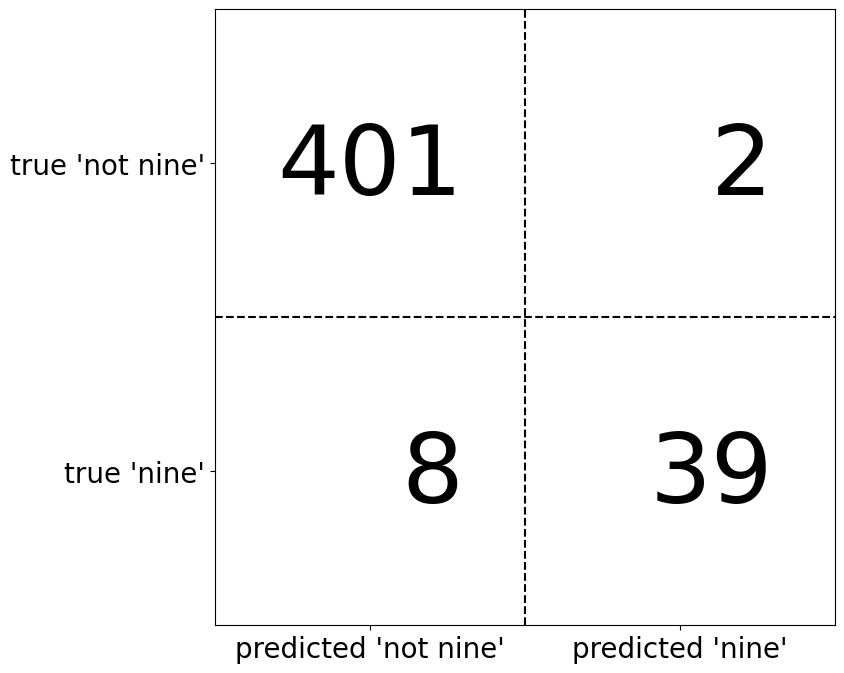

In [43]:
mglearn.plots.plot_confusion_matrix_illustration()

Entries on the main diagonal3 of the confusion matrix correspond to correct classifications, while other entries tell us how many samples of one class got mistakenly classified as another class.

If we declare “a nine” the positive class, we can relate the entries of the confusion matrix with the terms false positive and false negative that we introduced earlier. To complete the picture, we call correctly classified samples belonging to the positive class true positives and correctly classified samples belonging to the negative class true negatives. These terms are usually abbreviated FP, FN, TP, and TN and lead to the following interpretation for the confusion matrix

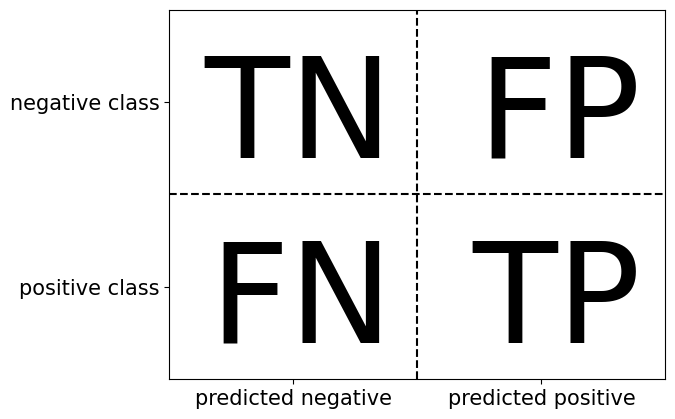

In [44]:
mglearn.plots.plot_binary_confusion_matrix()

Now let's use the confusion matrix to compare all the models we fitted:

In [45]:
print("Most frequent class:")
print(confusion_matrix(y_test, pred_most_frequent))
print("\nDummy model:")
print(confusion_matrix(y_test, pred_dummy))
print("\nDecision tree:")
print(confusion_matrix(y_test, pred_tree))
print("\nLogistic Regression")
print(confusion_matrix(y_test, pred_logreg))

Most frequent class:
[[403   0]
 [ 47   0]]

Dummy model:
[[403   0]
 [ 47   0]]

Decision tree:
[[390  13]
 [ 24  23]]

Logistic Regression
[[402   1]
 [  6  41]]


An analysis of the confusion matrix reveals a clear discrepancy in model performance, where pred_most_frequent fails by consistently predicting a single class, while pred_dummy yields an alarmingly low number of true positives compared to its frequent false positives. In contrast, although the decision tree exhibits accuracy levels similar to the dummy models, its predictions are significantly more logical and robust. Ultimately, logistic regression emerges as the superior approach, outperforming the decision tree across all metrics by maximizing true results while minimizing both false positives and false negatives. While this manual inspection of the confusion matrix provides essential qualitative insights into these differences, the process remains somewhat cumbersome, suggesting a need for the more concise summary metrics that we will explore in the following section.

### **3.6. Precision, Recall, and F-Score**

To evaluate our model's effectiveness, we need to look at **Accuracy**, which can be derived directly from the confusion matrix:

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

Essentially, accuracy represents the proportion of correct classifications—both true positives and true negatives—relative to the entire dataset.

However, accuracy alone often isn't enough. We need **Precision** to quantify the reliability of our positive predictions:

$$\text{Precision} = \frac{TP}{TP + FP}$$

Precision serves as a critical metric when our primary objective is to minimize false positives. For instance, in drug efficacy trials, it is vital that the model doesn't falsely claim a drug is effective when it isn't; thus, high precision (or Positive Predictive Value) is mandatory.

In contrast, **Recall** indicates the model's ability to identify all relevant instances within the positive class:

$$\text{Recall} = \frac{TP}{TP + FN}$$

We prioritize recall—also referred to as Sensitivity or True Positive Rate—when failing to detect a positive case carries a high cost. A classic example is cancer diagnosis, where missing a positive case (a false negative) could have dire consequences.

It is important to note the inherent trade-off between these two metrics. While we could theoretically achieve perfect recall by classifying every sample as positive, our precision would suffer due to an influx of false positives. Conversely, a highly conservative model might achieve perfect precision by only flagging the most certain case, but it would result in extremely poor recall.

To balance these two, we often use the **$F_1$-score**. This metric is the harmonic mean of precision and recall:

$$F_1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}} = \frac{2 \cdot TP}{2 \cdot TP + FP + FN}$$

The advantage of using the harmonic mean over a simple average is its sensitivity to imbalances; the $F_1$-score will only be high if both precision and recall are strong. To see how this works in practice, let's apply these calculations to our "nine vs. rest" classification results:

In [46]:
from sklearn.metrics import f1_score
print("f1 score most frequent: {:.2f}".format(
    f1_score(y_test, pred_most_frequent, zero_division=0)))
print("f1 score dummy: {:.2f}".format(f1_score(y_test, pred_dummy, zero_division=0)))
print("f1 score tree: {:.2f}".format(f1_score(y_test, pred_tree)))
print("f1 score logistic regression: {:.2f}".format(
    f1_score(y_test, pred_logreg)))

f1 score most frequent: 0.00
f1 score dummy: 0.00
f1 score tree: 0.55
f1 score logistic regression: 0.92


We can note two things here. First, we get an error message for the most_frequent prediction, as there were no predictions of the positive class (which makes the denominator in the f-score zero). Also, we can see a pretty strong distinction between the dummy predictions and the tree predictions, which wasn’t clear when looking at accuracy alone. Using the f-score for evaluation, we summarized the predictive performance again in one number. However, the f-score seems to capture our intuition of what makes a good model much better than accuracy did. A disadvantage of the f-score, however, is that it is harder to interpret and explain than accuracy.

If we want a more comprehensive summary, we can use the classification_report convenience function to compute precision, recall, and $F_1$ for each class:

In [47]:
from sklearn.metrics import classification_report
print(classification_report(y_test, pred_most_frequent,
                            target_names=["not nine", "nine"], zero_division=0))

              precision    recall  f1-score   support

    not nine       0.90      1.00      0.94       403
        nine       0.00      0.00      0.00        47

    accuracy                           0.90       450
   macro avg       0.45      0.50      0.47       450
weighted avg       0.80      0.90      0.85       450



The classification_report function provides a detailed breakdown for each class—in this case, "True" and "False"—by calculating precision, recall, and f-score, treating each class as the positive one in turn. While we previously focused on the minority class ("nine") as our positive label, shifting that focus to the "not nine" class reveals an f-score of 0.94 when using the most_frequent model. Notably, this model achieves a recall of 1 for the "not nine" class because it predictably classifies every instance as such. The report also includes a 'support' column, which simply indicates the actual frequency of each class in our ground truth data, while the final row offers a weighted average of these metrics based on class distribution. To provide further context, we can now compare these findings with the subsequent reports generated for both the dummy classifier and the logistic regression model.

Here are the reports for the dummy classifier and the logistic regression:

In [48]:
print(classification_report(y_test, pred_dummy,
                            target_names=["not nine", "nine"], zero_division=0))

              precision    recall  f1-score   support

    not nine       0.90      1.00      0.94       403
        nine       0.00      0.00      0.00        47

    accuracy                           0.90       450
   macro avg       0.45      0.50      0.47       450
weighted avg       0.80      0.90      0.85       450



In [49]:
print(classification_report(y_test, pred_logreg,
                            target_names=["not nine", "nine"]))

              precision    recall  f1-score   support

    not nine       0.99      1.00      0.99       403
        nine       0.98      0.87      0.92        47

    accuracy                           0.98       450
   macro avg       0.98      0.93      0.96       450
weighted avg       0.98      0.98      0.98       450



As you may notice when looking at the reports, the differences between the dummy
models and a very good model are not as clear any more. Picking which class is
declared the positive class has a big impact on the metrics. While the f-score for the dummy classification is 0.13 (vs. 0.89 for the logistic regression) on the “nine” class, for the “not nine” class it is 0.90 vs. 0.99, which both seem like reasonable results. Looking at all the numbers together paints a pretty accurate picture, though, and we can clearly see the superiority of the logistic regression model.

### **3.7. Taking Uncertainty into Account**

While the confusion matrix and classification report offer a comprehensive breakdown of model performance, it is important to recognize that relying solely on final predictions often overlooks the nuanced information embedded within the model's internal logic. As previously established, most classifiers utilize methods like decision_function or predict_proba to quantify prediction certainty, where the final classification is essentially determined by applying a fixed threshold—typically $0$ for decision functions or $0.5$ for probability estimates in binary scenarios. To illustrate this, we can examine an imbalanced dataset consisting of 400 negative and 50 positive samples; by training a kernel SVM, the resulting decision function values can be visualized as a heat map. In this context, the decision boundary is represented by a threshold of exactly zero, where the model effectively separates the classes based on whether a data point falls within or beyond this specific boundary.

In [50]:
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=[400, 50], centers=np.array([[0, 0], [5, 5]]),
                  cluster_std=[7.0, 2], random_state=22)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)
svc = SVC(gamma=.05).fit(X_train, y_train)

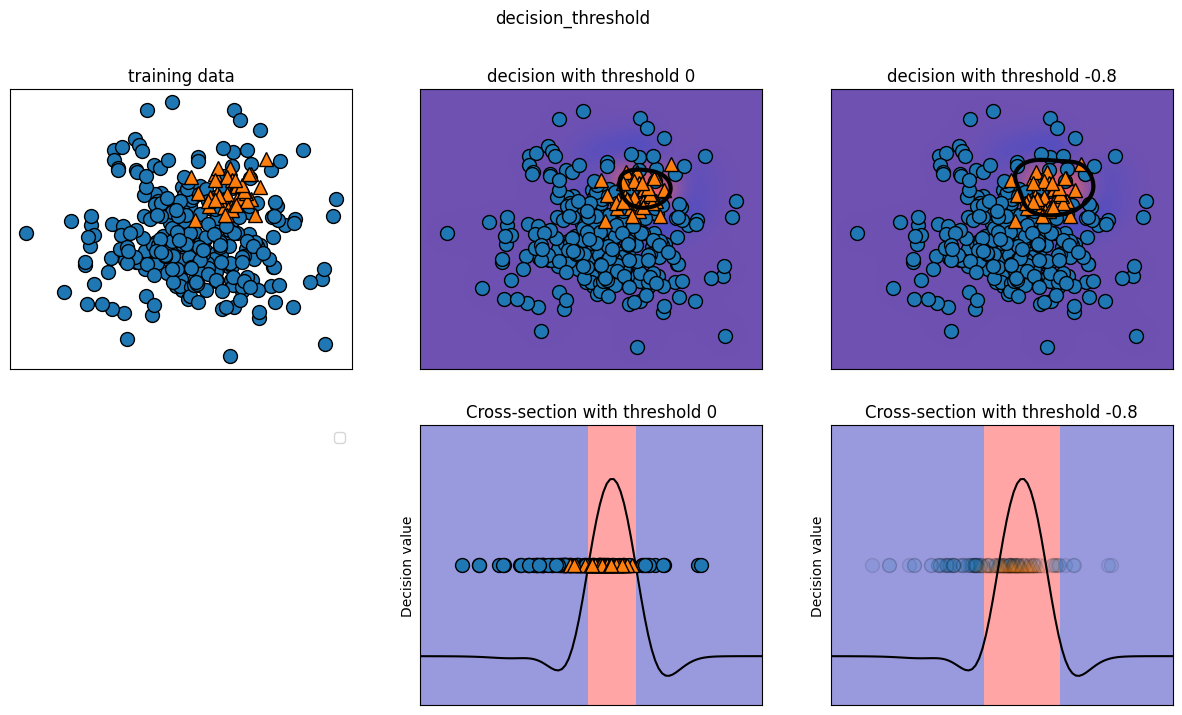

In [51]:
mglearn.plots.plot_decision_threshold()

The plots show the values of the decision function as a heat map. The black circle denotes the threshold of the decision function being exactly zero. Points inside this circle will be classified as the positive class (class 1), and points outside as the negative class (class 0). We can evaluate precision and recall for both classes:

In [52]:
print(classification_report(y_test, svc.predict(X_test)))

              precision    recall  f1-score   support

           0       0.85      1.00      0.92        96
           1       0.00      0.00      0.00        17

    accuracy                           0.85       113
   macro avg       0.42      0.50      0.46       113
weighted avg       0.72      0.85      0.78       113



For class 1, we get zero recall and zero precision -- the classifier fails to identify any positive samples at the default threshold. Because class 0 is so much larger, the classifier focuses entirely on getting class 0 right.

Let's assume it is more important to have a high recall for class 1 (as in cancer screening). We can adjust the predictions by changing the decision threshold away from 0:

In [53]:
y_pred_lower_threshold = svc.decision_function(X_test) > -.8

In [54]:
print(classification_report(y_test, y_pred_lower_threshold))

              precision    recall  f1-score   support

           0       0.90      0.98      0.94        96
           1       0.78      0.41      0.54        17

    accuracy                           0.89       113
   macro avg       0.84      0.70      0.74       113
weighted avg       0.88      0.89      0.88       113



Adjusting the decision threshold serves as a highly effective lever for balancing precision and recall, particularly when dealing with significant class imbalances or specific performance priorities. As expected, lowering the threshold expands the classification space for the positive class, typically boosting recall at the expense of precision. However, since the decision_function often yields arbitrary ranges, selecting an optimal threshold can be challenging and must always be validated using a separate validation set or cross-validation—rather than the test set—to avoid overly optimistic performance estimates. While models implementing predict_proba offer a more intuitive 0 to 1 scale for thresholding, it is crucial to remain mindful of model calibration; a model's high confidence does not always equate to accuracy, especially in uncalibrated structures like deep decision trees. Thus, while manipulating probabilities provides a more granular level of control, the reliability of these results ultimately hinges on how accurately the model represents its own uncertainty.

### **3.8. Precision-Recall Curves and ROC Curves**

Adjusting the classification threshold allows us to calibrate the trade-off between precision and recall, ensuring the model aligns with specific business objectives or operational requirements. For instance, prioritizing a high recall, such as 90%, is often necessary to minimize false negatives, though the primary challenge lies in maintaining acceptable precision to ensure the model remains practically useful. This selection of a specific performance target is formally known as establishing an 'operating point,' a crucial step for providing reliability guarantees in professional settings. However, since the optimal operating point is not always apparent during the initial stages of development, it is more effective to evaluate the model's performance across all potential thresholds simultaneously. This comprehensive analysis is facilitated by the precision-recall curve, which can be implemented using the sklearn.metrics module by evaluating the ground truth against the model's predicted probabilities or decision scores.

In [55]:
from sklearn.metrics import precision_recall_curve
precision, recall, thresholds = precision_recall_curve(
    y_test, svc.decision_function(X_test))

The precision_recall_curve function returns precision and recall values for all possible thresholds in sorted order, so we can plot a curve. Let's use more data points for a smoother curve:

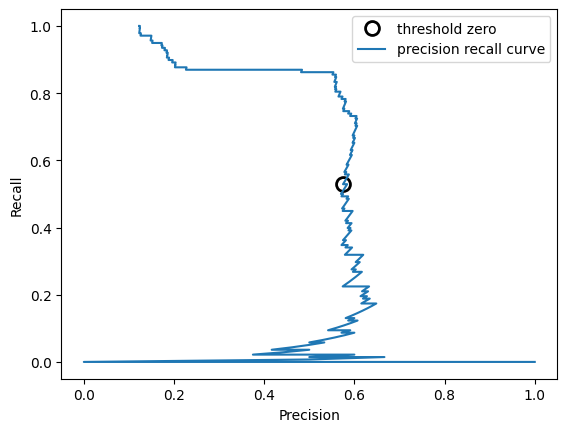

In [56]:
# Use more data points for a smoother curve
X, y = make_blobs(n_samples=[4000, 500], centers=np.array([[0, 0], [5, 5]]),
                  cluster_std=[7.0, 2], random_state=22)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

svc = SVC(gamma=.05).fit(X_train, y_train)
precision, recall, thresholds = precision_recall_curve(
    y_test, svc.decision_function(X_test))

# find threshold closest to zero
close_zero = np.argmin(np.abs(thresholds))
plt.plot(precision[close_zero], recall[close_zero], 'o', markersize=10,
         label="threshold zero", fillstyle="none", c='k', mew=2)

plt.plot(precision, recall, label="precision recall curve")
plt.xlabel("Precision")
plt.ylabel("Recall")
plt.legend(loc="best")

As illustrated in previous Figure, each coordinate on the curve represents a specific threshold for the decision_function, where the marked black circle identifies the default threshold of zero—the operational trade-off point utilized by the predict method. A high-performing classifier is characterized by a trajectory that gravitates toward the upper-right corner, signaling the model's ability to maintain high precision and recall simultaneously. While the curve typically begins at a point of maximum recall by classifying all instances as positive, incrementally raising the threshold enhances precision at the inevitable expense of recall, a trend that becomes particularly aggressive beyond the 0.5 precision mark in this specific model. Furthermore, evaluating different architectures, such as comparing a Support Vector Machine with a Random Forest, necessitates utilizing appropriate certainty measures—specifically predict_proba for the latter—to identify the optimal operating point where the model sustains a high recall even as precision requirements are tightened.

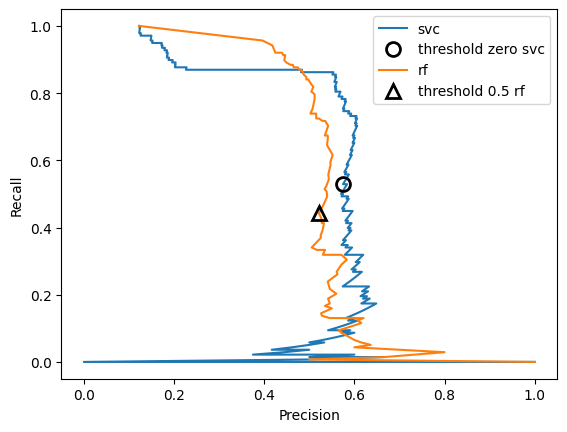

In [57]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=0, max_features=2)
rf.fit(X_train, y_train)

# RandomForestClassifier has predict_proba, but not decision_function
precision_rf, recall_rf, thresholds_rf = precision_recall_curve(
    y_test, rf.predict_proba(X_test)[:, 1])

plt.plot(precision, recall, label="svc")
plt.plot(precision[close_zero], recall[close_zero], 'o', markersize=10,
         label="threshold zero svc", fillstyle="none", c='k', mew=2)

plt.plot(precision_rf, recall_rf, label="rf")
close_default_rf = np.argmin(np.abs(thresholds_rf - 0.5))
plt.plot(precision_rf[close_default_rf], recall_rf[close_default_rf], '^', c='k',
         markersize=10, label="threshold 0.5 rf", fillstyle="none", mew=2)

plt.xlabel("Precision")
plt.ylabel("Recall")
plt.legend(loc="best")

From the comparison plot we can see how the two classifiers perform at different operating points. If we only looked at the $F_1$-score to compare overall performance, we would miss these subtleties. The $F_1$-score only captures one point on the precision-recall curve, the one given by the default threshold:

In [58]:
print("f1_score of random forest: {:.3f}".format(
    f1_score(y_test, rf.predict(X_test))))
print("f1_score of svc: {:.3f}".format(f1_score(y_test, svc.predict(X_test))))

f1_score of random forest: 0.472
f1_score of svc: 0.553


Comparing two precision-recall curves provides a lot of detailed insight, but is a fairly manual process. For automatic model comparison, we might want to summarize the information contained in the curve, without limiting ourselves to a particular thresh old or operating point. One particular way to summarize the precision-recall curve is by computing the integral or area under the curve of the precision-recall curve, also known as the average precision.4 You can use the average_precision_score function to compute the average precision. Because we need to compute the ROC curve and consider multiple thresholds, the result of decision_function or predict_proba needs to be passed to average_precision_score, not the result of predict:

In [59]:
from sklearn.metrics import average_precision_score
ap_rf = average_precision_score(y_test, rf.predict_proba(X_test)[:, 1])
ap_svc = average_precision_score(y_test, svc.decision_function(X_test))
print("Average precision of random forest: {:.3f}".format(ap_rf))
print("Average precision of svc: {:.3f}".format(ap_svc))

Average precision of random forest: 0.519
Average precision of svc: 0.532


When averaging over all possible thresholds, the SVM and random forest perform similarly. This is different from the result we got from $F_1$ alone.

### **3.9. Receiver Operating Characteristics (ROC) and AUC**

Beyond the precision-recall analysis, the Receiver Operating Characteristics (ROC) curve serves as a standard diagnostic tool for evaluating a classifier's performance across various decision thresholds. Much like the precision-recall approach, the ROC curve systematically maps out all potential thresholds; however, it specifically illustrates the trade-off between the False Positive Rate (FPR) and the True Positive Rate (TPR). It is important to note that while TPR is functionally equivalent to recall (or sensitivity), the FPR represents the proportion of negative instances that were incorrectly classified as positive, providing a comprehensive view of the model's discriminatory power.

$$\text{FPR} = \frac{FP}{FP + TN}$$

The ROC curve can be computed using the roc_curve function:

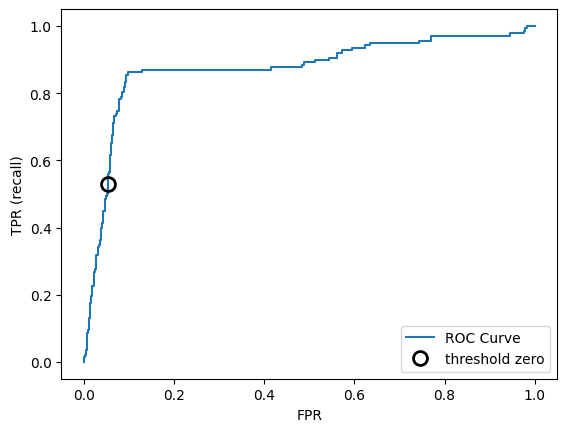

In [60]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, svc.decision_function(X_test))

plt.plot(fpr, tpr, label="ROC Curve")
plt.xlabel("FPR")
plt.ylabel("TPR (recall)")
# find threshold closest to zero
close_zero = np.argmin(np.abs(thresholds))
plt.plot(fpr[close_zero], tpr[close_zero], 'o', markersize=10,
         label="threshold zero", fillstyle="none", c='k', mew=2)
plt.legend(loc=4)

For the ROC curve, the ideal curve is close to the top left: you want a classifier that produces a high recall (TPR) while keeping a low false positive rate (FPR). A diagonal line from $(0, 0)$ to $(1, 1)$ represents a random classifier, and any curve above the diagonal is doing better than chance.

You can find a comparison of the random forest and the SVM using ROC curves in the following plot:

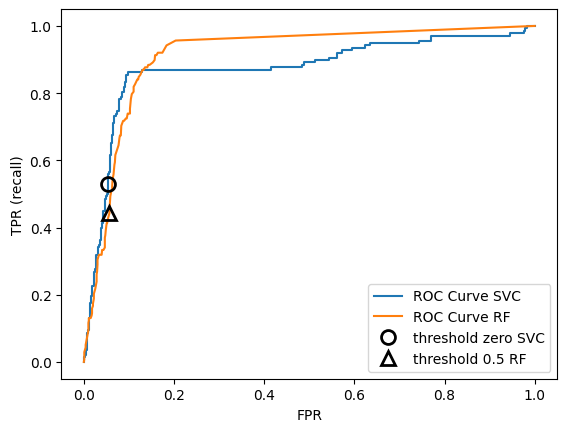

In [61]:
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, rf.predict_proba(X_test)[:, 1])

plt.plot(fpr, tpr, label="ROC Curve SVC")
plt.plot(fpr_rf, tpr_rf, label="ROC Curve RF")

plt.xlabel("FPR")
plt.ylabel("TPR (recall)")
plt.plot(fpr[close_zero], tpr[close_zero], 'o', markersize=10,
         label="threshold zero SVC", fillstyle="none", c='k', mew=2)
close_default_rf = np.argmin(np.abs(thresholds_rf - 0.5))
plt.plot(fpr_rf[close_default_rf], tpr_rf[close_default_rf], '^', markersize=10,
         label="threshold 0.5 RF", fillstyle="none", c='k', mew=2)
plt.legend(loc=4)

A comparative analysis using the AUC metric reveals that the Random Forest model significantly outperforms the SVM, particularly when dealing with imbalanced datasets where standard accuracy often proves misleading. By evaluating the classifier's ability to rank positive instances higher than negative ones, AUC provides a robust performance measure ranging from 0.5 for random guessing to a perfect score of 1.0. Given that AUC effectively captures the probability that a randomly selected positive sample will outscore a negative one, it serves as a more meaningful criterion for model selection in our current study, which involves classifying digit '9' using an SVM across various kernel bandwidth configurations.

In [62]:
from sklearn.metrics import roc_auc_score
rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])
svc_auc = roc_auc_score(y_test, svc.decision_function(X_test))
print("AUC for Random Forest: {:.3f}".format(rf_auc))
print("AUC for SVC: {:.3f}".format(svc_auc))

AUC for Random Forest: 0.912
AUC for SVC: 0.874


Predicting randomly always produces an AUC of 0.5, no matter how imbalanced the classes. This makes AUC a much better metric for imbalanced classification problems than accuracy. For classification problems with imbalanced classes, using AUC for model selection is often much more meaningful than using accuracy.

Let's go back to the digits dataset, classifying digit 9 against the rest, with an SVM using three different values of $\gamma$:

gamma = 1.00  accuracy = 0.90  AUC = 0.50
gamma = 0.05  accuracy = 0.90  AUC = 1.00
gamma = 0.01  accuracy = 0.90  AUC = 1.00


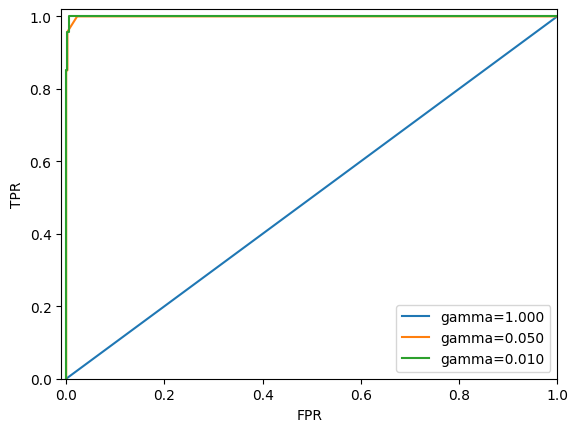

In [63]:
y = digits.target == 9
X_train, X_test, y_train, y_test = train_test_split(
    digits.data, y, random_state=0)

plt.figure()

for gamma in [1, 0.05, 0.01]:
    svc = SVC(gamma=gamma).fit(X_train, y_train)
    accuracy = svc.score(X_test, y_test)
    auc = roc_auc_score(y_test, svc.decision_function(X_test))
    fpr, tpr, _ = roc_curve(y_test, svc.decision_function(X_test))
    print("gamma = {:.2f}  accuracy = {:.2f}  AUC = {:.2f}".format(
        gamma, accuracy, auc))
    plt.plot(fpr, tpr, label="gamma={:.3f}".format(gamma))

plt.xlabel("FPR")
plt.ylabel("TPR")
plt.xlim(-0.01, 1)
plt.ylim(0, 1.02)
plt.legend(loc="best")

While the accuracy remains consistent at 90% across all three gamma settings, a closer examination of the AUC and its corresponding curves reveals significant performance disparities that accuracy alone fails to capture. At $\gamma = 1.0$, the model performs no better than random chance; however, reducing $\gamma$ to 0.05 notably improves the AUC, and at $\gamma = 0.01$, we achieve a perfect AUC of 1.0, indicating that the decision function ranks all positive instances correctly above negative ones. This demonstrates that with an appropriately adjusted threshold, the model is capable of perfect classification—an insight that would have remained hidden if we had relied solely on accuracy. Consequently, this highlights why AUC is a far more robust metric for evaluating imbalanced datasets, though it is important to remember that achieving a high AUC still necessitates manual threshold calibration to obtain optimal classification results.

## **4. Metrics for Multiclass Classification**

Having thoroughly explored binary classification metrics, we can now shift our focus toward multiclass classification, where the evaluation methods are essentially extensions of binary metrics averaged across all classes. While accuracy remains a standard measure defined by the ratio of correctly predicted instances, it remains inherently flawed when dealing with imbalanced datasets—such as a scenario where one class dominates $85\%$ of the data, making a high accuracy score potentially misleading. Given that multiclass results are naturally more complex to interpret, we typically rely on more robust diagnostic tools like the confusion matrix and the classification report to gain deeper insights. To demonstrate this, we will apply these evaluative frameworks to a practical case study involving the classification of ten distinct handwritten digits.

In [64]:
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    digits.data, digits.target, random_state=0)
lr = LogisticRegression(max_iter=5000).fit(X_train, y_train)
pred = lr.predict(X_test)
print("Accuracy: {:.3f}".format(accuracy_score(y_test, pred)))
print("Confusion matrix:\n{}".format(confusion_matrix(y_test, pred)))

Accuracy: 0.953
Confusion matrix:
[[37  0  0  0  0  0  0  0  0  0]
 [ 0 40  0  0  0  0  0  0  2  1]
 [ 0  0 41  3  0  0  0  0  0  0]
 [ 0  0  0 43  0  0  0  0  1  1]
 [ 0  0  0  0 37  0  0  1  0  0]
 [ 0  0  0  0  0 46  0  0  0  2]
 [ 0  1  0  0  0  0 51  0  0  0]
 [ 0  0  0  1  1  0  0 46  0  0]
 [ 0  3  1  0  0  0  0  0 43  1]
 [ 0  0  0  0  0  1  0  0  1 45]]


The model has an accuracy of 95.3%, which already tells us we are doing well. The confusion matrix provides more detail. Each row corresponds to a true label, and each column to a predicted label. Let's visualize it as a heatmap:

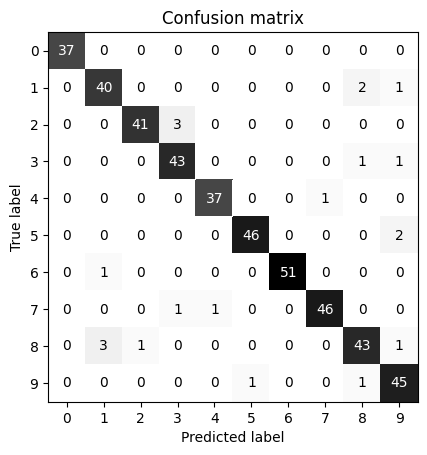

In [65]:
scores_image = mglearn.tools.heatmap(
    confusion_matrix(y_test, pred), xlabel='Predicted label',
    ylabel='True label', xticklabels=digits.target_names,
    yticklabels=digits.target_names, cmap=plt.cm.gray_r, fmt="%d")
plt.title("Confusion matrix")
plt.gca().invert_yaxis()

For the first class (digit 0), all 37 samples were correctly classified -- there are no false negatives and no false positives for class 0. Some digits were confused with others, though: for example, 3 instances of digit 2 were misclassified as digit 3, and 3 instances of digit 8 were misclassified as digit 1.

With the classification_report function, we can compute the precision, recall, and $F_1$-score for each class:

In [66]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        37
           1       0.91      0.93      0.92        43
           2       0.98      0.93      0.95        44
           3       0.91      0.96      0.93        45
           4       0.97      0.97      0.97        38
           5       0.98      0.96      0.97        48
           6       1.00      0.98      0.99        52
           7       0.98      0.96      0.97        48
           8       0.91      0.90      0.91        48
           9       0.90      0.96      0.93        47

    accuracy                           0.95       450
   macro avg       0.95      0.95      0.95       450
weighted avg       0.95      0.95      0.95       450



The classification results demonstrate an ideal performance for class 0, where both precision and recall reach a perfect score of 1.0, indicating a complete absence of misclassification. A similar trend is observed in class 7, which maintains perfect precision as no other categories were erroneously assigned to it, and class 6, which achieves a recall of 1.0 due to the absence of false negatives. However, the model’s predictive capability appears to diminish when encountering classes 8 and 3, suggesting these specific categories present a greater challenge for the current architecture to distinguish effectively.

To address the complexities of this multiclass imbalanced dataset, we utilize the multiclass F-score, which essentially aggregates binary F-scores calculated for each individual class. The final metric is derived through specific averaging strategies:
- "macro" averaging treats every class with equal importance regardless of frequency
- "weighted" averaging adjusts the mean based on the support of each class. Alternatively
- "micro" averaging pools the global counts of true positives and errors to determine the overall score.

Ultimately, the choice of metric depends on our research priority; we should opt for the micro-average if every individual sample is of equal concern, or the macro-average if we aim to evaluate the model’s performance across all classes with equal weight.

In [67]:
print("Micro average f1 score: {:.3f}".format(
    f1_score(y_test, pred, average="micro")))
print("Macro average f1 score: {:.3f}".format(
    f1_score(y_test, pred, average="macro")))

Micro average f1 score: 0.953
Macro average f1 score: 0.954


The micro and macro $F_1$-scores are nearly identical here (0.953 vs. 0.954), suggesting that the model performs similarly across all digit classes. In highly imbalanced multiclass problems, these numbers can differ significantly.

### **4.1. Regression Metrics**

While regression evaluation can be conducted with the same level of granularity as classification—such as by examining instances of overprediction versus underprediction—the default $R^2$ score remains the most common and practical metric for most applications. Although certain business-driven contexts may prioritize Mean Squared Error (MSE) or Mean Absolute Error (MAE) for model tuning to align with specific organizational objectives, $R^2$ is generally preferred in our analysis due to its more intuitive nature in interpreting model performance. Thus, unless specific operational requirements dictate otherwise, we will primarily rely on the $R^2$ coefficient to evaluate the efficacy of our regression models.

### **4.2. Using Evaluation Metrics in Model Selection**

Having thoroughly examined various evaluation techniques and their application based on ground truth data, we frequently encounter the need to integrate specific metrics like AUC directly into our model selection process, particularly when using GridSearchCV or cross_val_score. Fortunately, scikit-learn streamlines this integration through the scoring argument, which allows us to define the desired evaluation metric simply by passing a corresponding string. For instance, if we aim to evaluate an SVM classifier on the 'nine vs. rest' digits dataset using the AUC score instead of the default accuracy, we can easily achieve this by specifying 'roc_auc' as the scoring parameter, thereby ensuring our model selection is optimized for the most relevant performance indicator.

In [68]:
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC

# default scoring for classification is accuracy
print("Default scoring: {}".format(
    cross_val_score(SVC(), digits.data, digits.target == 9)))
# providing scoring="accuracy" doesn't change the results
explicit_accuracy = cross_val_score(SVC(), digits.data, digits.target == 9,
                                    scoring="accuracy")
print("Explicit accuracy scoring: {}".format(explicit_accuracy))
roc_auc = cross_val_score(SVC(), digits.data, digits.target == 9,
                          scoring="roc_auc")
print("AUC scoring: {}".format(roc_auc))

Default scoring: [0.975      0.99166667 1.         0.99442897 0.98050139]
Explicit accuracy scoring: [0.975      0.99166667 1.         0.99442897 0.98050139]
AUC scoring: [0.99717078 0.99854252 1.         0.999828   0.98400413]


The accuracy scores are high (0.975 to 1.0), but the AUC scores are even higher (0.984 to 1.0), reflecting the fact that AUC evaluates the ranking quality of the decision_function, not just the binary predictions. Similarly, we can change the metric used to pick the best parameters in GridSearchCV. This is where the choice of metric can have a significant impact:

In [69]:
from sklearn.model_selection import GridSearchCV

X_train, X_test, y_train, y_test = train_test_split(
    digits.data, digits.target == 9, random_state=0)

# we provide a somewhat bad grid to illustrate the point:
param_grid = {'gamma': [0.0001, 0.01, 0.1, 1, 10]}

# using the default scoring of accuracy:
grid = GridSearchCV(SVC(), param_grid=param_grid)
grid.fit(X_train, y_train)
print("Grid-Search with accuracy")
print("Best parameters:", grid.best_params_)
print("Best cross-validation score (accuracy): {:.3f}".format(grid.best_score_))
print("Test set AUC: {:.3f}".format(
    roc_auc_score(y_test, grid.decision_function(X_test))))
print("Test set accuracy: {:.3f}".format(grid.score(X_test, y_test)))

Grid-Search with accuracy
Best parameters: {'gamma': 0.0001}
Best cross-validation score (accuracy): 0.976
Test set AUC: 0.992
Test set accuracy: 0.973


In [70]:
# using AUC scoring instead:
grid = GridSearchCV(SVC(), param_grid=param_grid, scoring="roc_auc")
grid.fit(X_train, y_train)
print("Grid-Search with AUC")
print("Best parameters:", grid.best_params_)
print("Best cross-validation score (AUC): {:.3f}".format(grid.best_score_))
print("Test set AUC: {:.3f}".format(
    roc_auc_score(y_test, grid.decision_function(X_test))))
print("Test set accuracy: {:.3f}".format(grid.score(X_test, y_test)))

Grid-Search with AUC
Best parameters: {'gamma': 0.01}
Best cross-validation score (AUC): 0.998
Test set AUC: 1.000
Test set accuracy: 1.000


Selecting the appropriate evaluation metric is crucial, as demonstrated by the variance in optimal hyperparameters when switching between accuracy and AUC; specifically, a gamma value of $0.0001$ was optimal for the former, whereas $0.01$ was preferred for the latter, with AUC ultimately yielding superior results across both metrics. While accuracy serves as the default scoring parameter in scikit-learn for classification tasks, more nuanced alternatives such as roc_auc, average_precision, and various f1 configurations (including macro, micro, and weighted) are often more informative depending on the dataset's characteristics. Similarly, for regression analysis, metrics such as r2, mean_squared_error, and mean_absolute_error are standard benchmarks, all of which—along with many others—can be accessed via the SCORER dictionary in the metrics.scorer module or the official documentation.

In [71]:
from sklearn.metrics import get_scorer_names
print("Available scorers:\n{}".format(sorted(get_scorer_names())))

Available scorers:
['accuracy', 'adjusted_mutual_info_score', 'adjusted_rand_score', 'average_precision', 'balanced_accuracy', 'completeness_score', 'd2_absolute_error_score', 'explained_variance', 'f1', 'f1_macro', 'f1_micro', 'f1_samples', 'f1_weighted', 'fowlkes_mallows_score', 'homogeneity_score', 'jaccard', 'jaccard_macro', 'jaccard_micro', 'jaccard_samples', 'jaccard_weighted', 'matthews_corrcoef', 'mutual_info_score', 'neg_brier_score', 'neg_log_loss', 'neg_max_error', 'neg_mean_absolute_error', 'neg_mean_absolute_percentage_error', 'neg_mean_gamma_deviance', 'neg_mean_poisson_deviance', 'neg_mean_squared_error', 'neg_mean_squared_log_error', 'neg_median_absolute_error', 'neg_negative_likelihood_ratio', 'neg_root_mean_squared_error', 'neg_root_mean_squared_log_error', 'normalized_mutual_info_score', 'positive_likelihood_ratio', 'precision', 'precision_macro', 'precision_micro', 'precision_samples', 'precision_weighted', 'r2', 'rand_score', 'recall', 'recall_macro', 'recall_micro

### **5. Summary**

### **The Crucial Role of Evaluation and Parameter Tuning**

This chapter discussed the cornerstones of evaluating and improving machine learning algorithms. Building a model is only the first step; rigorously assessing its performance and fine-tuning its parameters are what make it truly applicable in the real world. There are several key points to keep in mind:

- Strict Separation of Data: To accurately estimate future performance, you must never use the test set to select model parameters. Using the test set for tuning leaks information into the model, leading to overly optimistic results. Always maintain a strict separation between training data (for building), validation data (for parameter selection, often via cross-validation), and test data (for final evaluation).

- Align Metrics with Business Goals: The end goal of a machine learning application is rarely just to achieve high mathematical accuracy. It is vital to understand the real-world consequences of your model's mistakes (e.g., the cost of false positives vs. false negatives) and choose an evaluation metric that reflects these business or clinical impacts.

- Accuracy is Not Always Enough: In reality, classification problems often involve imbalanced classes. In such scenarios, default accuracy is an inadequate indicator of true predictive power. Alternative metrics like AUC (Area Under the ROC Curve) and f-score provide much deeper and more reliable insights into how well your model actually distinguishes between classes.

### **Key Concepts**

- **Cross-Validation** A robust statistical method that repeatedly splits data into training and test sets (folds) to thoroughly evaluate a model's generalization capability. Variants like Stratified k-Fold ensure class balance across folds, while GroupKFold ensures related samples are kept in the same split to prevent data leakage.

- **Grid Search** A method for hyperparameter tuning that tries all possible combinations of parameters defined in a dictionary or grid. When combined with cross-validation (GridSearchCV), it effectively finds the parameters that yield the best generalization performance without compromising the final test set.

- **Confusion Matrix** A comprehensive 2x2 table showing the true positives, true negatives, false positives, and false negatives of a binary classification model, providing a granular view of exactly where the model is making mistakes.

- **Precision and Recall** Precision measures how many of the positively predicted samples are actually positive (crucial when false positives are costly), while Recall measures how many actual positive samples were successfully identified (crucial when missing a positive case is dangerous). The f-score (or $f_1$-score) is the harmonic mean of both, offering a better single-number summary than accuracy for imbalanced data.

- **ROC Curve and AUC** The Receiver Operating Characteristic (ROC) curve plots the True Positive Rate against the False Positive Rate across all possible classification thresholds. The Area Under the Curve (AUC) summarizes this curve into a single number. An AUC of 1.0 means perfect ranking, making it a highly reliable metric for comparing models on imbalanced datasets.

- **Multiclass Metrics** Multiclass evaluation builds upon binary metrics. Confusion matrices help visualize exactly which classes are being confused with one another, while "macro", "micro", or "weighted" averaging methods are used to compute overall precision, recall, and f-scores across multiple classes.